<a href="https://colab.research.google.com/github/Trista1208/advanced_genAI/blob/main/Step_1_Baseline_Setup_Full_corpus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Implementing and Evaluating Multiple Retrieval Strategies on the Subsample

## Dependencies

In [ ]:
!pip install bs4 docling langchain chromadb sentence-transformers \
             langchain-graph-retriever[chroma] --quiet
!pip install -U langchain-community
!pip install nltk
!pip install langdetect rank_bm25

import os
import json
import pickle
import re
import functools
from typing import List, Dict, Optional, Tuple

import nltk
nltk.download("punkt")      # for English tokenization
nltk.download("punkt_tab")  # needed for German tokenization

import torch
import langchain

from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.retrievers import BM25Retriever



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 6.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.4/275.4 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.0/223.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 129.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Detect the best available device: CUDA → MPS → CPU
if   torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"⮕ Using device: {DEVICE}")
# You can also enable cudnn benchmark for slight speedups on static-size inputs:
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True

# Common kwargs to pass into any HuggingFace model loader or LangChain embedder
MODEL_KWARGS = {
    "device": DEVICE,
    "trust_remote_code": True
}

⮕ Using device: cpu


## Loading the three datasets

The merged JSON files are loaded into into LangChain Document objects used for retrieval later.

In [ ]:
import pathlib

ROOT_DIR = pathlib.Path("/content/drive/MyDrive/Adv_GenAI/storage/general")

def load_documents_from_folder(subfolder: str) -> List[Document]:
    """
    Loads every .json file under ROOT_DIR/subfolder and
    returns a list of LangChain Documents.
    Handles JSON files with one or many records,
    and also files with list-of-lists structure.
    Each record must have:
      {
        "id": "...",
        "text": "...",
        "metadata": { ... }
      }
    We copy 'id' into metadata['record_id'] so it's globally unique.
    """
    docs: List[Document] = []
    folder_path = ROOT_DIR / subfolder

    for json_path in folder_path.rglob("*.json"):
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # flatten: handles dict, list of dict, or list of list of dict
        if isinstance(data, dict):
            records = [data]
        elif isinstance(data, list):
            # If list of lists, flatten
            if data and isinstance(data[0], list):
                records = [r for group in data for r in group]
            else:
                records = data
        else:
            print(f"Warning: {json_path} is not a dict or list, skipping.")
            continue

        for record in records:
            if not isinstance(record, dict):
                print(f"Warning: Record in {json_path} is not a dict, skipping.")
                continue
            text_content = record.get("text", "")
            md = record.get("metadata", {}) or {}
            md["record_id"] = record.get("id", "")
            docs.append(Document(page_content=text_content, metadata=md))

    return docs

# Usage
docs_fixed    = load_documents_from_folder("fixed_size_chunk")

print(f"Loaded fixed-size chunks: {len(docs_fixed)} documents")


Loaded fixed-size chunks: 7544 documents


## Filtering to English-German

 French and Italian documents are filtered out, keeping only English and German content.

In [ ]:
from collections import Counter

# Filter the chunk set
def filter_chunks_en_de(docs_fixed: List[Document], allowed_langs=("en","de")):
    """
    Filters out 'fr'/'it' from your chunk-level datasets as well (fixed-size).
    Returns the filtered version.
    """
    filtered_fixed = [doc for doc in docs_fixed if doc.metadata.get("language", "unknown") in allowed_langs]
    return filtered_fixed

filtered_fixed = filter_chunks_en_de(docs_fixed, allowed_langs=("en", "de"))

print(f"Filtered fixed-size chunks:   from {len(docs_fixed)} down to {len(filtered_fixed)}")

Filtered fixed-size chunks:   from 7544 down to 7531


In [ ]:
# quick check for correct format.
for label, docs in [
    ("Fixed-size chunks", filtered_fixed),
]:
    if not docs:
        print(f"{label}: <no documents loaded>\n")
        continue

    doc = docs[0]
    print(f"--- {label} sample ---")
    print("Text snippet:")
    print(doc.page_content[:200].replace("\n"," "), "...\n")
    print("Metadata:")
    for k, v in doc.metadata.items():
        v_str = v if isinstance(v, (str, int, float)) else repr(v)
        if k == "record_id":
            print(f"  {k}: {v_str}  <-- unique identifier")
        else:
            print(f"  {k}: {v_str}")
    print("\n")

--- Fixed-size chunks sample ---
Text snippet:
people animals and plants everyone and everything should feel at home: jörg dietz, institute of integrative biology hans hiltbrunner, its system services daniel sandro ménard, institute of technology  ...

Metadata:
  doc_id: cfad933d98a194fae4e9aa8a2cef8bb0875b5eda
  filename: people-animals-and-plants-everyone-and-everything-should-feel-at-home.html
  domain: ethz.ch
  language: en
  title: people animals and plants everyone and everything should feel at home
  year: 2015
  month: 7
  source: ETH News
  doc_named_entities: [{'text': 'second quarter 2015', 'label': 'DATE'}, {'text': '35 years', 'label': 'DATE'}, {'text': 'jörg brenn', 'label': 'ORG'}, {'text': 'dr pascal leuchtmann', 'label': 'PERSON'}, {'text': 'jörg', 'label': 'GPE'}, {'text': 'institute of chemical', 'label': 'ORG'}, {'text': 'david schmid', 'label': 'PERSON'}, {'text': '30 years', 'label': 'DATE'}, {'text': 'michael leopold', 'label': 'PERSON'}, {'text': 'albert', 'la

## Text Normalization (Stemming)

This function normalizes document text for retrieval by applying stemming—reducing words to their root forms.

In [ ]:
from nltk.stem import SnowballStemmer

def normalize_documents(docs: List[Document]) -> List[Document]:
    """
    For each Document in `docs`, we:
      1) Detect language from doc.metadata['language'] (default to 'en').
      2) Remove punctuation via regex.
      3) Tokenize (nltk word_tokenize).
      4) Stem with SnowballStemmer for English or German.
      5) Rejoin tokens into normalized text.
    Returns a new list of Documents with normalized text.
    """
    normalized_docs = []

    # Initialize stemmers
    stemmer_en = SnowballStemmer("english")
    stemmer_de = SnowballStemmer("german")

    for doc in docs:
        lang = doc.metadata.get("language", "en")
        text = doc.page_content.lower()

        # 1) Remove punctuation (anything not letter/number/whitespace)
        text_no_punct = re.sub(r"[^\w\säöüß]", "", text)

        # 2) Tokenize
        tokens = nltk.word_tokenize(
            text_no_punct, language="german" if lang == "de" else "english"
        )

        # 3) Stem with SnowballStemmer
        if lang == "de":
            stemmed_tokens = [stemmer_de.stem(t) for t in tokens]
        else:
            stemmed_tokens = [stemmer_en.stem(t) for t in tokens]

        # 4) Re-join into normalized text
        normalized_text = " ".join(stemmed_tokens)

        # 5) Copy metadata and add the original text
        new_metadata = dict(doc.metadata)
        new_metadata["original_text"] = doc.page_content

        # 6) Create a new Document with the normalized text and new metadata
        new_doc = Document(page_content=normalized_text, metadata=new_metadata)
        normalized_docs.append(new_doc)

    return normalized_docs

In [ ]:
# Normalize text (remove punctuation, tokenize, stem) for each chunk set for BM25
docs_fixed_norm    = normalize_documents(filtered_fixed)

#### Checking Samples
Before building any indexes, we do a quick check of the first few docs from each set (Doc-level, Fixed-size, Semantic) to confirm correct metadata, chunking, and content.


In [ ]:
# quick check for correct format.
for label, docs in [
    ("Fixed-size chunks", docs_fixed_norm),
]:
    if not docs:
        print(f"{label}: <no documents loaded>\n")
        continue

    doc = docs[0]
    print(f"--- {label} sample ---")
    print("Text snippet:")
    print(doc.page_content[:200].replace("\n"," "), "...\n")
    print("Metadata:")
    for k, v in doc.metadata.items():
        v_str = v if isinstance(v, (str, int, float)) else repr(v)
        if k == "record_id":
            print(f"  {k}: {v_str}  <-- unique identifier")
        else:
            print(f"  {k}: {v_str}")
    print("\n")


--- Fixed-size chunks sample ---
Text snippet:
peopl anim and plant everyon and everyth should feel at home jörg dietz institut of integr biolog han hiltbrunn it system servic daniel sandro ménard institut of technolog in architectur dr eva ruiz m ...

Metadata:
  doc_id: cfad933d98a194fae4e9aa8a2cef8bb0875b5eda
  filename: people-animals-and-plants-everyone-and-everything-should-feel-at-home.html
  domain: ethz.ch
  language: en
  title: people animals and plants everyone and everything should feel at home
  year: 2015
  month: 7
  source: ETH News
  doc_named_entities: [{'text': 'second quarter 2015', 'label': 'DATE'}, {'text': '35 years', 'label': 'DATE'}, {'text': 'jörg brenn', 'label': 'ORG'}, {'text': 'dr pascal leuchtmann', 'label': 'PERSON'}, {'text': 'jörg', 'label': 'GPE'}, {'text': 'institute of chemical', 'label': 'ORG'}, {'text': 'david schmid', 'label': 'PERSON'}, {'text': '30 years', 'label': 'DATE'}, {'text': 'michael leopold', 'label': 'PERSON'}, {'text': 'albert', 'la

In [ ]:
# Base path and subfolders
base_path       = "/content/drive/MyDrive/Adv_GenAI/storage/full_corpus"
lang_norm_dir   = os.path.join(base_path, "Lang_norm")

fixed_folder    = os.path.join(lang_norm_dir, "fixed_size_chunk")

# Ensure these directories exist
os.makedirs(fixed_folder,    exist_ok=True)

# File paths
fixed_norm_path     = os.path.join(fixed_folder,    "docs_fixed_norm.pkl")

# --- Saving each list of normalized Documents ---
with open(fixed_norm_path, "wb") as f:
    pickle.dump(docs_fixed_norm, f)

print("✅ Saved normalized documents to:")
print(f"  • {fixed_norm_path}")


# --- Loading them in a new session if needed ---
# with open(fixed_norm_path, "rb") as f:
#     docs_fixed_norm_loaded = pickle.load(f)

# print("✅ Loaded normalized docs back into memory.")
# print(f"Fixed-size count: {len(docs_fixed_norm_loaded)}")

✅ Saved normalized documents to:
  • /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/Lang_norm/fixed_size_chunk/docs_fixed_norm.pkl


## BM25 Retrieval (Multilingual Baseline)

The BM25 retrieval is a ranking function for text retrieval that scores how relevant a document is to a search query.

This module implements cross-lingual BM25 retrieval for English and German documents. It can translate queries to search both language indexes effectively.

In [ ]:
import functools
import re
import pickle
from typing import List, Dict, Optional, Tuple

import nltk
from nltk.stem import SnowballStemmer
from langdetect import detect
from transformers import (
    M2M100ForConditionalGeneration,
    M2M100Tokenizer
)
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever

###############################################################################
# Fast Bilingual Translator (English <-> German)
###############################################################################
class EnDeTranslator:
    """
    Simple translator for English <-> German queries using a smaller or
    more efficient model if desired, e.g. 'Helsinki-NLP/opus-mt-en-de'.

    For demonstration, we still use facebook/m2m100_418M with:
      - num_beams=1 (greedy decoding)
      - max_new_tokens=128
    """

    def __init__(self, model_name: str = "facebook/m2m100_418M", device: str = "cpu"):
        self.tokenizer = M2M100Tokenizer.from_pretrained(model_name)
        self.model = M2M100ForConditionalGeneration.from_pretrained(model_name).to(device)
        self.device = device

    @functools.lru_cache(maxsize=512)
    def translate(self, text: str, target_lang: str) -> str:
        # Detect source language (fallback to "en" if not recognized)
        src_lang = detect(text)
        if src_lang not in ("en", "de"):
            src_lang = "en"

        # If the source language == target language, no translation needed
        if src_lang == target_lang:
            return text

        self.tokenizer.src_lang = src_lang
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(self.device)

        forced_id = self.tokenizer.get_lang_id(target_lang)
        outputs = self.model.generate(
            **inputs,
            forced_bos_token_id=forced_id,
            num_beams=1,          # greedy for speed
            max_new_tokens=128
        )
        return self.tokenizer.decode(outputs[0], skip_special_tokens=True)


###############################################################################
# BilingualBM25 for English–German
###############################################################################
class BilingualBM25:
    """
    Builds a BM25Retriever for English and one for German.
    Does cross-lingual search by translating the query if needed.
    Returns merged & deduplicated results.

    If 'translator' is None, *no translation* will occur, meaning:
      - Query is used as-is on both English and German indexes.
      - This is only recommended if your queries/documents are mostly
        in the same language, or if you attach a translator after loading.
    """

    def __init__(
        self,
        docs: List[Document],
        translator: Optional[EnDeTranslator] = None,
        bm25_k1: float = 1.2,
        bm25_b: float = 0.75,
    ):
        # Translator can be None (for easy pickling or if no cross-lingual is required)
        self.translator = translator
        self.k1, self.b = bm25_k1, bm25_b

        # Bucket docs by language ("en" or "de")
        buckets: Dict[str, List[Document]] = {"en": [], "de": []}
        for doc in docs:
            lang = doc.metadata.get("language", "en")
            if lang in ("en", "de"):
                buckets[lang].append(doc)

        # Build a separate BM25 retriever for each language
        self.retrievers: Dict[str, BM25Retriever] = {}
        for lang in ("en", "de"):
            if buckets[lang]:
                self.retrievers[lang] = BM25Retriever.from_documents(
                    buckets[lang], k1=self.k1, b=self.b
                )

    def detect_language(self, query: str) -> str:
        """Detect query language (fallback to 'en' if detection fails or is not 'en'/'de')."""
        try:
            lang = detect(query)
            if lang not in ("en", "de"):
                lang = "en"
        except:
            lang = "en"
        return lang

    def _apply_meta_filter(
        self,
        docs: List[Document],
        flt : Optional[dict]
    ) -> List[Document]:
        """
        Very small *exact-match AND* filter.

        • Scalar   →  doc.metadata[k] == v
        • List/Set →  doc.metadata[k] in v
        • Missing  →  doc is rejected

        Example
        -------
        flt = {"year": 2024,
               "document_type": "article",
               "language": ["en", "de"]}
        """
        if not flt:
            return docs                          # nothing to filter

        def ok(d: Document) -> bool:
            meta = d.metadata
            for k, v in flt.items():
                val = meta.get(k, None)
                if   isinstance(v, (list, set, tuple)):
                    if val not in v:
                        return False
                else:                            # scalar
                    if val != v:
                        return False
            return True

        return [d for d in docs if ok(d)]

    def search(
        self,
        query: str,
        top_k: int = 5,
        metadata_filter: Optional[dict] = None
    ) -> List[Document]:
        """
        1) Detect language of query.
        2) If translator is present and the language of the index differs from the query,
          translate query accordingly.
        3) Retrieve from both English & German BM25 indexes, combine results.
        4) Sort by BM25 score, deduplicate, return top_k.
        """
        src_lang = self.detect_language(query)
        all_hits: List[Tuple[Document, float]] = []

        for lang, retriever in self.retrievers.items():
            # If we have a translator, and the language differs, we translate.
            if self.translator is not None and lang != src_lang:
                q = self.translator.translate(query, lang)
            else:
                q = query

            # Retrieve top_k hits from BM25 with scores (the magic line!)
            try:
                hits_with_scores = retriever.get_relevant_documents_with_scores(q, k=top_k)
            except AttributeError:
                # For older versions, hack: only get docs, not scores
                hits = retriever.get_relevant_documents(q, k=top_k)
                hits_with_scores = [(doc, doc.metadata.get("score", 0.0)) for doc in hits]

            # Filter by metadata (if needed)
            for doc, score in hits_with_scores:
                if not metadata_filter or doc in self._apply_meta_filter([doc], metadata_filter):
                    doc.metadata["bm25_score"] = float(score)
                    all_hits.append((doc, score))

        # Sort by BM25 score (descending) and deduplicate by 'record_id'
        seen = set()
        unique_hits = []
        for doc, score in sorted(all_hits, key=lambda x: x[1], reverse=True):
            rid = doc.metadata.get("record_id") or doc.metadata.get("chunk_id")
            if rid not in seen:
                seen.add(rid)
                doc.metadata["bm25_score"] = float(score)
                unique_hits.append(doc)
            if len(unique_hits) >= top_k:
                break

        return unique_hits

### Building & Saving BM25 Indexes

In [ ]:
# Define the base folder and subfolders
base_folder     = "/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/retrieval"
fixedsize_folder = os.path.join(base_folder, "fixed_size_chunk")

# Create directories if they don't exist
os.makedirs(fixedsize_folder, exist_ok=True)

In [ ]:
import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print("Using DEVICE =", DEVICE)

Using DEVICE = cuda


In [ ]:
#  Build & save the fixed-size chunks index
print("\nBuilding BM25 index for Fixed-Size Chunks...")
bm25_fixed = BilingualBM25(docs=docs_fixed_norm, translator=EnDeTranslator(device=DEVICE))
bm25_fixed.translator = None
fixed_pickle_path = os.path.join(fixedsize_folder, "bm25_retriever_full.pkl")
with open(fixed_pickle_path, "wb") as f:
    pickle.dump(bm25_fixed, f)
print(f"Fixed-size chunks index saved to {fixed_pickle_path}")


Building BM25 index for Fixed-Size Chunks...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

Fixed-size chunks index saved to /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/retrieval/fixed_size_chunk/bm25_retriever_full.pkl


## Comparative Evaluation of Multilingual BM25

### Dependencies

In [ ]:
# ==============================================================
# Imports & one-time set-up
# ==============================================================
!pip install bs4 docling langchain chromadb sentence-transformers \
             langchain-graph-retriever[chroma] --quiet
!pip install -U langchain-community
!pip install nltk
!pip install langdetect rank_bm25
!pip install pytrec_eval

import pathlib, json, pickle, functools, itertools, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
from typing import List, Dict, Optional, Tuple
import nltk, pytrec_eval, torch
from langdetect import detect
from tqdm.auto import tqdm
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever
from transformers import M2M100Tokenizer, M2M100ForConditionalGeneration

# NLTK & tokenizers
import nltk
nltk.download("punkt",  quiet=True)  # for English tokenization
nltk.download("punkt_tab", quiet=True)  # sometimes used for German tokenization
nltk.download("stopwords", quiet=True)

STOP_EN = set(nltk.corpus.stopwords.words("english"))
STOP_DE = set(nltk.corpus.stopwords.words("german"))

# Core LangChain imports
import langchain
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.retrievers import BM25Retriever

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("🖥️ Using device:", DEVICE)

  Preparing metadata (setup.py) ... done
  Created wheel for pytrec_eval: filename=pytrec_eval-0.5-cp312-cp312-linux_x86_64.whl size=309348 sha256=0ff7525a7942ba0e92606b733b96c9f0cc9ce3b01f06ff1a35ca29fcdea53ef3
  Stored in directory: /root/.cache/pip/wheels/c6/4a/9e/e17f9ea004e1c221bd0ff384732285211c4917b790d598ea51
Successfully built pytrec_eval
🖥️ Using device: cuda


### Tiny Translator

Translates text between English and German using Facebook's M2M100 model.

In [ ]:
class EnDeTranslator:
    """Greedy EN⇄DE MT; cached so subsequent calls are instant."""
    def __init__(self, name="facebook/m2m100_418M", device="cpu"):
        self.tok   = M2M100Tokenizer.from_pretrained(name)
        self.model = M2M100ForConditionalGeneration.from_pretrained(name).to(device)
        self.device = device

    @functools.lru_cache(maxsize=512)
    def translate(self, txt: str, tgt: str) -> str:
        lang = detect(txt)
        src = lang if lang in ("en", "de") else "en"

        if src == tgt:
            return txt
        self.tok.src_lang = src
        ids  = self.tok(txt, return_tensors="pt").to(self.device)
        gen  = self.model.generate(**ids,
                                   forced_bos_token_id=self.tok.get_lang_id(tgt),
                                   num_beams=1, max_new_tokens=128)
        return self.tok.decode(gen[0], skip_special_tokens=True)

translator = EnDeTranslator(device=DEVICE)


### Bilingual BM25

This is a refined version of BilingualBM25 with more robust score extraction that handles different LangChain retriever API versions.

The main enhancement is a fallback chain for getting BM25 scores, since LangChain's API has changed across versions:

In [ ]:
class BilingualBM25:
    """
    * Two BM25 indices (EN / DE)
    * Optional ⟶ cross-translate query via self.translator
    * Optional ⟶ metadata_filter {'year':2024, 'document_type':['article','news']}
    """
    def __init__(self, docs: List[Document], translator=None, k1=1.2, b=0.75):
        self.translator = translator
        buckets = {"en": [], "de": []}
        for d in docs:
            buckets[d.metadata.get("language", "en")].append(d)
        self.retrievers = {lang: BM25Retriever.from_documents(v, k1=k1, b=b)
                           for lang, v in buckets.items() if v}

    def _lang(self, q: str) -> str:
        try:
            l = detect(q)
            return l if l in ("en", "de") else "en"
        except Exception:
            return "en"

    def _filter(self, docs: List[Document], flt: Optional[dict]) -> List[Document]:
        if not flt:
            return docs
        def ok(d):
            for k, v in flt.items():
                dv = d.metadata.get(k)
                if isinstance(v, (list, tuple, set)):
                    if dv not in v:
                        return False
                else:
                    if dv != v:
                        return False
            return True
        return [d for d in docs if ok(d)]

    def _get_docs_with_scores(self, ret, qq, top_k):
        """Get documents with scores from any retriever type."""

        # Method 1: Try standard API with scores
        if hasattr(ret, "get_relevant_documents_with_scores"):
            try:
                return ret.get_relevant_documents_with_scores(qq, k=top_k)
            except Exception:
                pass

        # Method 2: BM25 direct scoring (vectorizer + docs)
        if hasattr(ret, "vectorizer") and hasattr(ret, "docs"):
            try:
                tokens = qq.lower().split()
                scores = ret.vectorizer.get_scores(tokens)
                ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)[:top_k]
                return [(ret.docs[idx], float(score)) for idx, score in ranked]
            except Exception:
                pass

        # Method 3: invoke (modern API)
        if hasattr(ret, "invoke"):
            try:
                if hasattr(ret, 'k'):
                    old_k = ret.k
                    ret.k = top_k
                    docs = ret.invoke(qq)
                    ret.k = old_k
                else:
                    docs = ret.invoke(qq)[:top_k]
                return [(d, d.metadata.get("score", 0.0)) for d in docs]
            except Exception:
                pass


        # Last resort
        return []

    def search(self, q: str, top_k=100, metadata_filter=None) -> List[Document]:
        src = self._lang(q)
        bag: List[Tuple[Document, float]] = []

        for lang, ret in self.retrievers.items():
            qq = self.translator.translate(q, lang) if self.translator and lang != src else q

            docs_with_scores = self._get_docs_with_scores(ret, qq, top_k)

            for doc, score in docs_with_scores:
                bag.append((doc, score))

        # Apply metadata filtering if needed
        if metadata_filter:
            bag = [(doc, score) for doc, score in bag
                  if doc in self._filter([doc], metadata_filter)]

        # Merge duplicates (keep best BM25 score)
        best = {}
        id2doc = {}
        for d, score in bag:
            did = d.metadata.get("chunk_id") or d.metadata.get("record_id")
            if did not in best or score > best[did]:
                best[did] = score
                id2doc[did] = d

        ranked = sorted(best.items(), key=lambda x: x[1], reverse=True)[:top_k]

        # Set bm25_score in metadata before returning
        result = []
        for did, score in ranked:
            doc = id2doc[did]
            doc.metadata["bm25_score"] = float(score)
            result.append(doc)

        return result

### Load pre-built BM25 indices

In [ ]:
%%time
BASE = pathlib.Path("/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/retrieval")

IDX = {"fixed": BASE / "fixed_size_chunk/bm25_retriever_full.pkl"}

bm25 = {n: pickle.load(open(p, "rb")) for n, p in IDX.items()}

for obj in bm25.values():          # deserialised with translator=None
    obj.translator = translator

print("📚 Indices loaded:", list(bm25.keys()))



📚 Indices loaded: ['fixed']
CPU times: user 373 ms, sys: 98.1 ms, total: 471 ms
Wall time: 474 ms


## Pre-Retrieval Strategies

### Automatic Acronym / Spelling Resource

Acronyming is a pre-retrieval optimization that builds an acronym lookup table from the corpus. It helps expand query acronyms to their full forms for better matching.

In [ ]:
for idx in bm25.values():
    for lang, ret in idx.retrievers.items():
        for d in ret.docs[:5]:
            print(d.page_content[:200])
            break

peopl anim and plant everyon and everyth should feel at home jörg dietz institut of integr biolog han hiltbrunn it system servic daniel sandro ménard institut of technolog in architectur dr eva ruiz m
eth library 2017 annual report quiz on the annual report ent our quiz on the annual reporthttpwwwlibraryethzchenueberunsoeffentlichkeitsarbeitpublikationenquizzumjahresbericht2017 by 29 august 2018 an


In [ ]:
import re
# Harvest acronyms from the corpus
def harvest_acronyms(indices: Dict[str, BilingualBM25]) -> Dict[str, str]:
    short2long = defaultdict(lambda: defaultdict(int))
    PAREN = re.compile(r"\(([^)]+?)\)")
    for idx in indices.values():
        for _, ret in idx.retrievers.items():
            for d in ret.docs:
                txt = d.page_content
                # a) “ERC (European Research Council)”
                for m in PAREN.finditer(txt):
                    long = m.group(1).strip()
                    before = txt[:m.start()].split()[-1] if m.start() else ""
                    short  = before.strip(",.;:-–—() ")
                    if 2<=len(short)<=6 and short.isupper():
                        short2long[short.lower()][long] += 1
                # b) stand-alone ALL-CAPS tokens
                for t in re.findall(r"\b[a-z]{2,6}\b", txt):
                    short2long[t.lower()][t.title()] += 1
    return {s: max(c, key=c.get) for s,c in short2long.items()}

ACRONYM_LUT = harvest_acronyms(bm25)          # ≈ 4 s for ~1 k chunks
print(f"🔎 Harvested {len(ACRONYM_LUT)} acronym candidates")

🔎 Harvested 15629 acronym candidates


### Language Routing

Language Routing works by detecting the query language and directing it only to the matching-language sub-index, thereby avoiding irrelevant cross-lingual matches.




In [ ]:
# ---- Routing: send query only to the sub-index in the same language ----
class RoutedBM25:
    def __init__(self, base):
        self.b = base

    def search(self, q, top_k=100, metadata_filter=None):
        lang = self.b._lang(q)

        # safe fallback
        if lang not in self.b.retrievers:
            lang = next(iter(self.b.retrievers))

        ret = self.b.retrievers[lang]

        # Use the helper function from BilingualBM25
        return self.b._get_docs_with_scores(ret, q, top_k)

### Bilingual Re-write

Bilingual re-write concatenates the original query with its translation, then searches using the combined bilingual query.

In [ ]:
# ---- Rewrite: bilingual concatenation ----------------------------------
def _rewrite(q, tr):
    if tr is None:
      return q
    l = detect(q) if q.strip() else "en"
    other = tr.translate(q, "de" if l == "en" else "en")
    return f"{q} {other}"
class RewrittenBM25:
    def __init__(self, base): self.b = base
    def search(self, q, top_k=100, metadata_filter=None):
        return self.b.search(_rewrite(q, self.b.translator), top_k, metadata_filter)

### Spelling / Acronym Expansion

We automatically expand acronyms and abbreviations in the query using a lexicon mined directly from the corpus. This increases the likelihood of matching both short and long forms in the documents, improving retrieval for technical and news queries.


In [ ]:
def _spell(q: str) -> str:
    extra = []
    for t in q.split():
        k = t.lower()
        if k in ACRONYM_LUT:
            v = ACRONYM_LUT[k]
            if isinstance(v, str):
                extra.append(v)
    return q if not extra else f"{q} {' '.join(extra)}"

class SpellBM25:
    """Expand in-query acronyms using corpus-mined LUT."""
    def __init__(self, base):
        self.b = base

    def search(self, q, top_k=100, metadata_filter=None):
        return self.b.search(_spell(q), top_k, metadata_filter)

### Temporal Routing

When a user query mentions a specific year, we automatically restrict retrieval to only those chunks whose metadata year (year or content_year) falls within a ±1 year window around the query year. By focusing the search on the most relevant temporal context, this approach reduces noise and might improve precision in time-sensitive news retrieval scenarios.

In [ ]:
# Helper to extract year from query
_YEAR = re.compile(r"(19|20)\d{2}")
def _year(q: str) -> Optional[int]:
    m = _YEAR.search(q)
    return int(m.group()) if m else None

class TemporalBM25:
    """
    If query mentions a year, restrict search to chunks whose
    metadata.year OR metadata.content_year ∈ {y-1, y, y+1}.
    """
    def __init__(self, base): self.b = base
    def search(self, q, top_k=100, metadata_filter=None):
        y = _year(q)
        flt = (metadata_filter or {}).copy()
        if y:
            # Supply tuple as key: ('year', 'content_year')
            flt[("year", "content_year")] = list(range(y-1, y+2))
        return self.b.search(q, top_k, flt if y else metadata_filter)

### Query Expansion

We expand the query with top terms from initial retrieval hits, boosting recall by capturing related vocabulary in the corpus.



In [ ]:
def _expand(q, base, fb_docs=5, fb_terms=5):
    hits = base.search(q, fb_docs)
    if not hits:
      return q
    toks = [t for h in hits for t in nltk.word_tokenize(h.page_content.lower())
            if t.isalpha() and t not in STOP_EN and t not in STOP_DE]
    if not toks:
      return q
    exp = " ".join(w for w, _ in nltk.FreqDist(toks).most_common(fb_terms))
    return f"{q} {exp}"
class QEBM25:
    def __init__(self, base): self.b = base
    def search(self, q, top_k=100, metadata_filter=None):
        return self.b.search(_expand(q, self.b), top_k, metadata_filter)

VARIANTS = {
    "BM25"   : lambda b: b,
    "Routing": RoutedBM25,
    "Rewrite": RewrittenBM25,
    "QE"     : QEBM25,
    "Spell"  : SpellBM25,
    "Temp"   : TemporalBM25
}

ID2LABEL = {     # human-readable headings for result tables
    "P_5"        : "Precision@5",
    "P_10"       : "Precision@10",
    "recall_100" : "Recall@100",
    "recip_rank" : "MRR",
    "ndcg_cut_10": "nDCG@10"
}


## Evaluation and Metric Interpretation

To assess the effectiveness of each pre-retrieval method and chunking strategy, we report five standard retrieval metrics:

- **Mean Reciprocal Rank (MRR):** Indicates how early the first relevant chunk appears in the ranked results, with higher values rewarding methods that return relevant answers near the top.
- **Precision@5** and **Precision@10:** The fraction of retrieved chunks among the top 5 or 10 results that are relevant—these metrics focus on early precision, which is especially important for user-facing retrieval.
- **Recall@100:** The proportion of all relevant (“gold”) chunks retrieved in the top 100—this reflects a method’s ability to cover the gold set in a large candidate pool.
- **nDCG@10 (Normalized Discounted Cumulative Gain):** Rewards retrieval of highly relevant chunks in top positions, using graded (not just binary) relevance when available.

In [ ]:
def load_qrels(folder: pathlib.Path) -> dict:
    qrels = defaultdict(dict)
    for fp in folder.glob("*.json"):
        did = fp.stem
        for qid, pay in json.loads(fp.read_text()).items():
            if pay["relevance_score"] >= 0.5:        # binary threshold
                qrels[qid][did] = 1
    return qrels

QRELS = {"fixed":   load_qrels(pathlib.Path("/content/drive/MyDrive/Adv_GenAI/benchmark/score/fixed_size"))}

QUESTIONS = json.loads(pathlib.Path("/content/drive/MyDrive/Adv_GenAI/benchmark/benchmark_qa_bilingual.json").read_text())
print(f"✔ Qrels loaded fixed_size – {len(QRELS['fixed'])} queries with judgements")
print(f"✔ Questions loaded – {len(QUESTIONS)}")

✔ Qrels loaded fixed_size – 24 queries with judgements
✔ Questions loaded – 25


### Run all Combinations

In [ ]:
def build_runs(idx_name: str) -> Dict[str, dict]:
    base = bm25[idx_name]
    runs = {}

    for vname, wrapper in VARIANTS.items():
        retr = wrapper(base) if callable(wrapper) else wrapper
        run = defaultdict(dict)

        for q in tqdm(QUESTIONS, desc=f"{idx_name}/{vname}", leave=False):
            qid = str(q["id"])
            results = retr.search(q["question"], top_k=100)

            for rk, item in enumerate(results, 1):
                # Handle both tuple (doc, score) and plain Document
                if isinstance(item, tuple):
                    d, score = item
                else:
                    d = item
                    score = d.metadata.get("bm25_score", 0.0)

                did = d.metadata.get("chunk_id") or d.metadata.get("record_id")
                run[qid][did] = 100 - rk  # simple descending score

        runs[vname] = run

    return runs

runs_fixed = build_runs("fixed")

fixed/BM25:   0%|          | 0/25 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


fixed/Routing:   0%|          | 0/25 [00:00<?, ?it/s]

fixed/Rewrite:   0%|          | 0/25 [00:00<?, ?it/s]

fixed/QE:   0%|          | 0/25 [00:00<?, ?it/s]

fixed/Spell:   0%|          | 0/25 [00:00<?, ?it/s]

fixed/Temp:   0%|          | 0/25 [00:00<?, ?it/s]

### Metrics for all Combinations

In [ ]:
METRICS = {"P_5","P_10","recall_100","recip_rank","ndcg_cut_10"}
def macro(run,qrels):
    df = (pd.DataFrame(pytrec_eval.RelevanceEvaluator(qrels,METRICS)
                       .evaluate(run)).T)
    return df.mean().rename(ID2LABEL)

tbl_fixed = pd.concat({k: macro(r,QRELS["fixed"])   for k,r in runs_fixed.items()}, axis=1).T.round(3)

## Results overview

In [ ]:
print("\nTable 1 – Fixed-size chunks (24 Qs)")
display(tbl_fixed.style.format("{:.3f}"))


Table 1 – Fixed-size chunks (24 Qs)


,MRR,Precision@5,Precision@10,Recall@100,nDCG@10
BM25,0.153,0.083,0.096,0.080,0.087
Routing,0.185,0.092,0.104,0.084,0.097
Rewrite,0.092,0.042,0.050,0.049,0.046
QE,0.103,0.058,0.079,0.063,0.068
Spell,0.156,0.067,0.083,0.082,0.078
Temp,0.165,0.091,0.105,0.087,0.095


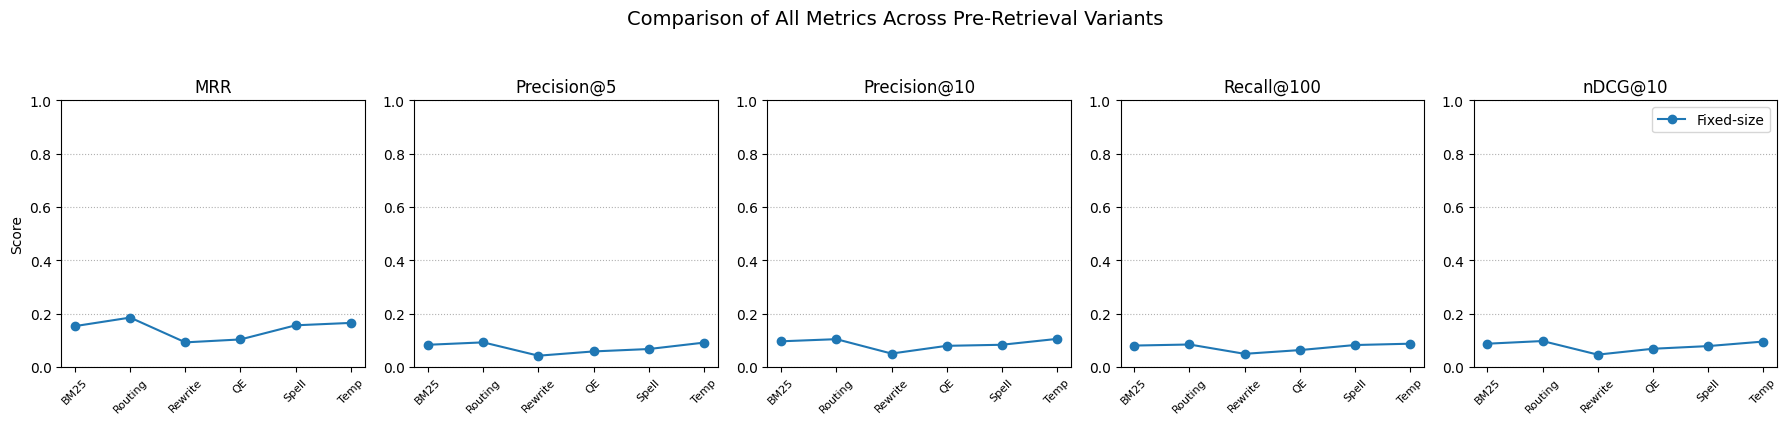

In [ ]:
metrics_to_plot = ["MRR", "Precision@5", "Precision@10", "Recall@100", "nDCG@10"]
num_metrics = len(metrics_to_plot)

fig, axes = plt.subplots(1, num_metrics, figsize=(18, 4), sharex=True)

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    ax.plot(tbl_fixed[metric], marker="o", label="Fixed-size")
    ax.set_title(metric)
    ax.set_xticks(range(len(tbl_fixed)))
    ax.set_xticklabels(tbl_fixed.index, rotation=45, fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", ls=":")
    if i == 0:
        ax.set_ylabel("Score")
    if i == num_metrics - 1:
        ax.legend(loc='upper right')

fig.suptitle("Comparison of All Metrics Across Pre-Retrieval Variants", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

# Dense Retrieval with Multilingual E5

While classic IR models like BM25 rely on exact lexical matching, dense retrieval approaches fundamentally change the retrieval paradigm: both queries and document chunks are embedded into a high-dimensional vector space using a neural language model, and retrieval is based on semantic similarity rather than surface-level overlap.


## Dependencies

In [ ]:
!pip install --upgrade transformers huggingface_hub
!pip install langchain_community
!pip install chromadb

EMBED_MODEL = "intfloat/multilingual-e5-large-instruct"   # 1024-d, 605 MB
from langchain_core.documents import Document
import pickle, pathlib, tqdm, os, json, torch, pathlib
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma


Pre-normalized document collections saved as pickle files and the embedding model is setup.

In [ ]:
DATA_DIR = pathlib.Path("/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/Lang_norm")

PICKLES = {
    "fixed_size_chunk": DATA_DIR / "fixed_size_chunk/docs_fixed_norm.pkl",
}

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

INDEX_ROOT = pathlib.Path(
    "/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/vectordb_dense"
)
INDEX_ROOT.mkdir(parents=True, exist_ok=True)


embeddings = HuggingFaceEmbeddings(
        model_name   = EMBED_MODEL,
        model_kwargs = {"device": DEVICE},
        encode_kwargs= {"batch_size": 32, "normalize_embeddings": True},
)

/tmp/ipython-input-608694401.py:15: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_xlm-roberta_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

## Restoration

This cell loads the normalized documents and restores the original text for dense retrieval, adding the prefix required by E5 embedding models.

In [ ]:
# ------------------------------------------------------------------
# 1. restore_original: returns pristine text Documents
# ------------------------------------------------------------------
def restore_original(docs_norm):
    """
    Build a fresh Document list whose page_content holds *original* text
    (lower-case/stemmed text is only in docs_norm.page_content).
    Adds the 'passage:' prefix required by E5-family models.
    """
    out = []
    for d in docs_norm:
        raw = d.metadata.get("original_text") or d.page_content
        meta = dict(d.metadata)  # shallow copy
        out.append(Document(page_content=f"passage: {raw}", metadata=meta))
    return out


# ------------------------------------------------------------------
# 2. load all pickle files & restore
# ------------------------------------------------------------------
corpora = {}

for label, pkl in PICKLES.items():
    if not pkl.exists():
        raise FileNotFoundError(f"✗ {pkl} not found")

    print(f"→ loading {label} … ", end="", flush=True)
    with open(pkl, "rb") as f:
        docs_norm = pickle.load(f)

    docs_orig = restore_original(docs_norm)
    corpora[label] = docs_orig

    print(f"{len(docs_orig):>5} docs")


→ loading fixed_size_chunk …  7531 docs


## Loading, Inspecting, and Validating Corpora

The sanity check function validates the loaded documents to ensure the expected structure before building expensive vector indexes.

In [ ]:
# ------------------------------------------------------------------
# 3. validation / sanity-check helper
# ------------------------------------------------------------------
def verbose_check(docs, label):
    doc = docs[0]
    print(f"\n===== FULL METADATA DUMP — {label} =====")
    print(doc.page_content[:500])
    for k, v in doc.metadata.items():
        print(f"{k:<20} : {str(v)[:120]}")

    required_any = {"record_id", "chunk_id"}
    required_all = {"language"}

    assert any(k in doc.metadata for k in required_any), \
        f"Missing identifier key (one of {required_any})"
    assert required_all.issubset(doc.metadata), \
        f"Missing keys: {required_all - set(doc.metadata)}"

    print("✓ required keys present")


verbose_check(corpora["fixed_size_chunk"], "fixed_size_chunk")


===== FULL METADATA DUMP — fixed_size_chunk =====
passage: people animals and plants everyone and everything should feel at home: jörg dietz, institute of integrative biology hans hiltbrunner, its system services daniel sandro ménard, institute of technology in architecture dr eva ruiz muller, institute of pervasive computing dr christoph küffer schumacher, environmental systems science dominic dähler, department of biology **10 years** dr isabelle herter-aeberli, institute of food, nutrition and health gianni antonitti, its service delivery mi
doc_id               : cfad933d98a194fae4e9aa8a2cef8bb0875b5eda
filename             : people-animals-and-plants-everyone-and-everything-should-feel-at-home.html
domain               : ethz.ch
language             : en
title                : people animals and plants everyone and everything should feel at home
year                 : 2015
month                : 7
source               : ETH News
doc_named_entities   : [{'text': 'second quarter 20

## Building, Storing, and Persisting Dense Vector Indices

Chroma vector indexes are built for dense retrieval, with metadata sanitization to handle Chroma's type restrictions.

In [ ]:
# ---------------------------------------------------------------
# Helpers to refine metadata for Chroma
# ---------------------------------------------------------------
def _simple(val):
    """Return True if val is already a primitive Chroma accepts."""
    return isinstance(val, (str, int, float, bool)) or val is None

def simplify_metadata(meta: dict) -> dict:
    """Copy meta, JSON-encode any non-primitive values."""
    out = {}
    for k, v in meta.items():
        out[k] = v if _simple(v) else json.dumps(v, ensure_ascii=False)
    return out

def sanitize_docs(docs_raw: list[Document]) -> list[Document]:
    cleaned = []
    for d in docs_raw:
        cleaned.append(
            Document(page_content=d.page_content,
                     metadata=simplify_metadata(d.metadata))
        )
    return cleaned

# ---------------------------------------------------------------
# Build & persist one or more indexes
# ---------------------------------------------------------------
def build_index(label: str, docs_raw):
    docs = sanitize_docs(docs_raw)           # <- flatten metadata
    idx_dir = INDEX_ROOT / f"{label}_e5"
    idx_dir.mkdir(parents=True, exist_ok=True)

    vectordb = Chroma.from_documents(
        documents         = docs,
        embedding         = embeddings,
        persist_directory = str(idx_dir)
    )
    vectordb.persist()
    print(f"✅  {label} index stored at {idx_dir}")
    return vectordb

vectordb_fixed = build_index("fixed", corpora["fixed_size_chunk"])

✅  fixed index stored at /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/vectordb_dense/fixed_e5


/tmp/ipython-input-2551055640.py:37: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist()


In [ ]:
vectordb_fixed._collection.count()


7531

## DenseRetriever Class

To provide a consistent interface for querying and evaluating dense retrieval, a `DenseRetriever` wrapper class is implemented around the Chroma vector store.

In [ ]:
!pip install -qU langchain-community langchain-huggingface


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document

class DenseRetriever:
    """
    Wrapper around a LangChain VectorStore (e.g. Chroma) that:
      • adds the E5 'query:' prefix
      • converts cosine *distance* (lower → better) to similarity (higher → better)
    """
    def __init__(self, vectordb, k: int = 100):
        self.store = vectordb
        self.k     = k

    def _prep(self, q: str) -> str:
        return "query: " + q.strip()

    def search(self, query: str, top_k: int | None = None):
        k = top_k or self.k
        docs_scores = self.store.similarity_search_with_score(
            self._prep(query), k=k
        )  # returns List[Tuple[Document, float]]

        results = []
        for doc, dist in docs_scores:
            sim = 1 - float(dist)           # distance → similarity
            doc.metadata["dense_score"] = sim
            results.append(doc)
        return results

# ---------------------------------------------------------------
# 2. Instantiate retrievers
# ---------------------------------------------------------------
dense_fixed = DenseRetriever(vectordb_fixed, k=100)


# ---------------------------------------------------------------
# 3. Quick sanity query
# ---------------------------------------------------------------
for d in dense_fixed.search("ETH quantum dots", top_k=5):
    print(f"{d.metadata['dense_score']:.3f}  {d.metadata.get('title','')[:60]}")


0.732  how to make bright quantum dots even brighter
0.727  how to make bright quantum dots even brighter
0.723  review 2020
0.722  a quantum simulator for magnetic materials
0.718  eliminating resistant bacteria with nanoparticles


## Evaluation and Comparative Metrics

In [ ]:
# ───────────────────────────────────────────────────────────────
# 0.  One-time imports / helpers  (reuse if already defined)
# ───────────────────────────────────────────────────────────────
!pip install pytrec_eval

from collections import defaultdict
import pandas as pd, pytrec_eval
from tqdm.auto import tqdm
from typing import List, Dict, Optional, Tuple

METRICS = {"P_5", "P_10", "recall_100", "recip_rank", "ndcg_cut_10"}
ID2LABEL = {               # prettify column names
    "P_5": "Precision@5",
    "P_10": "Precision@10",
    "recall_100": "Recall@100",
    "recip_rank": "MRR",
    "ndcg_cut_10": "nDCG@10",
}

def build_run(retriever, questions, top_k=100):
    """
    Run dense search for every question and return a
    `run` dict  {qid: {doc_id: score}} compatible with pytrec_eval.
    """
    run = defaultdict(dict)
    for q in tqdm(questions, desc="dense-search", leave=False):
        qid = str(q["id"])
        for doc in retriever.search(q["question"], top_k=top_k):
            did = (
                doc.metadata.get("chunk_id")
                or doc.metadata.get("record_id")
            )
            run[qid][did] = float(doc.metadata["dense_score"])
    return run

def macro(run, qrels):
    """
    Compute per-query metrics then average (macro-avg).
    Returns a pandas Series with nice column names.
    """
    ev = pytrec_eval.RelevanceEvaluator(qrels, METRICS).evaluate(run)
    df = pd.DataFrame(ev).T         # one row per query
    return df.mean().rename(ID2LABEL)

In [ ]:
# ───────────────────────────────────────────────────────────────
# 1.  Build run-files for the dense indices
# ───────────────────────────────────────────────────────────────
run_dense_fixed   = build_run(dense_fixed, QUESTIONS, top_k=100)

# ───────────────────────────────────────────────────────────────
# 2.  Compute metrics
# ───────────────────────────────────────────────────────────────
metrics_dense_fixed = macro(run_dense_fixed, QRELS["fixed"])

# ───────────────────────────────────────────────────────────────
# 3.  Append to the existing result tables (created in BM25 section)
#    – if the tables are not in memory any more, just create them anew
# ───────────────────────────────────────────────────────────────
if "tbl_fixed" not in globals():
    tbl_fixed = pd.DataFrame()

tbl_fixed.loc["Dense"] = metrics_dense_fixed

dense-search:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
RESULT_DIR = pathlib.Path(
    "/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/results"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
csv_fixed   = RESULT_DIR / "tbl_fixed.csv"
tbl_fixed.to_csv(csv_fixed)
print("✅ Results saved:")
print("   •", csv_fixed)

# import pandas as pd, pickle, pathlib
# RES_DIR = pathlib.Path("/content/drive/MyDrive/GenAI/storage/subsample/results")
# tbl_fixed  = pd.read_csv(RES_DIR / "tbl_fixed.csv", index_col=0)
# tbl_sem    = pd.read_csv(RES_DIR / "tbl_sem.csv",   index_col=0)

✅ Results saved:
   • /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/results/tbl_fixed.csv


### Results Overview

In [ ]:
print("Fixed-size chunks – Dense vs. BM25 variants")
display(tbl_fixed.round(3))

Fixed-size chunks – Dense vs. BM25 variants


,MRR,Precision@5,Precision@10,Recall@100,nDCG@10
BM25,0.153,0.083,0.096,0.080,0.087
Routing,0.185,0.092,0.104,0.084,0.097
Rewrite,0.092,0.042,0.050,0.049,0.046
QE,0.103,0.058,0.079,0.063,0.068
Spell,0.156,0.067,0.083,0.082,0.078
Temp,0.165,0.091,0.105,0.087,0.095
Dense,0.166,0.058,0.067,0.128,0.071


## Persisting and Reloading for Downstream Use

This is the setup to store the best model and reload it later.

In [ ]:
import pathlib, textwrap, torch


EMBED_MODEL = "intfloat/multilingual-e5-large-instruct"
INDEX_DIR   = pathlib.Path("/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/vectordb_dense/fixed_e5")
LOADER_FILE = INDEX_DIR.parent / "load_dense_fixed.py"

code = f"""
import torch
from pathlib import Path
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

from langchain_core.documents import Document   # only for type hints

class DenseRetriever:
    \"\"\"Light wrapper that adds the e5 'query:' prefix and returns similarity\"\"\"
    def __init__(self, vectordb, k: int = 100):
        self.store, self.k = vectordb, k
    def _prep(self, q: str) -> str:          # e5 query format
        return 'query: ' + q.strip()
    def search(self, query: str, top_k: int | None = None):
        k = top_k or self.k
        hits = self.store.similarity_search_with_score(self._prep(query), k=k)
        docs = []
        for doc, dist in hits:               # cosine *distance*
            doc.metadata['dense_score'] = 1.0 - float(dist)
            docs.append(doc)
        return docs

def load_dense_fixed(device: str | None = None, k: int = 100) -> DenseRetriever:
    \"\"\"Factory – returns a DenseRetriever ready for inference\"\"\"
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    embeds = HuggingFaceEmbeddings(
        model_name   = '{EMBED_MODEL}',
        model_kwargs = {{'device': device}},
        encode_kwargs={{'batch_size': 32, 'normalize_embeddings': True}},
    )
    vectordb = Chroma(
        persist_directory = str(Path(r\"{INDEX_DIR}\")),
        embedding_function = embeds,
    )
    return DenseRetriever(vectordb, k=k)
"""

LOADER_FILE.write_text(textwrap.dedent(code))
print("✅ Loader written to", LOADER_FILE)


✅ Loader written to /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/vectordb_dense/load_dense_fixed.py


In [ ]:
import pathlib, textwrap

stub = pathlib.Path(
    "/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/vectordb_dense/load_dense_fixed.py"
)

txt = stub.read_text()

# reload
import importlib.util, importlib, sys
spec = importlib.util.spec_from_file_location("ldf", stub)
ldf  = importlib.util.module_from_spec(spec); spec.loader.exec_module(ldf)

dense_fixed = ldf.load_dense_fixed(k=100)   # now works
for d in dense_fixed.search("ETH quantum dots", top_k=5):
    print(f"{d.metadata['dense_score']:.3f}", d.metadata.get('title','')[:60])

0.732 how to make bright quantum dots even brighter
0.727 how to make bright quantum dots even brighter
0.723 review 2020
0.722 a quantum simulator for magnetic materials
0.718 eliminating resistant bacteria with nanoparticles


/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/vectordb_dense/load_dense_fixed.py:32: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectordb = Chroma(


# GraphRAG

Instead of treating each text chunk as an isolated vector, Graph-RAG structures the corpus into a richly connected entity- and event-graph, overlaid with hierarchical community detection and LLM-driven summarization.

## Dependencies

In [ ]:
# ──────────────────────────────  Python env  ──────────────────────────────
!pip install -q igraph leidenalg sentence-transformers openai
!pip install pytrec_eval
!pip install python-dotenv

import igraph as ig, leidenalg as la
from collections import defaultdict
import json, os, pathlib, pickle, random, textwrap, dotenv
import numpy as np
from pathlib import Path

import pandas as pd, pytrec_eval, torch, tqdm
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from langchain_core.documents import Document
from openai import OpenAI
dotenv.load_dotenv()

tqdm.pandas();  pd.set_option("display.precision", 3)

# global clients/paths
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


# ── OpenAI client ───────────────────────────────────────────────────
from google.colab import userdata
client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 107.8 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Defnition of some paths and functions to save results.

In [ ]:
# Canonical Root
STORAGE = Path("/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/retrieval_graph")
STORAGE.mkdir(parents=True, exist_ok=True)

# Sub-folder registry
SUM_DIR   = STORAGE / "comm_summaries" ; SUM_DIR.mkdir(exist_ok=True)
GRAPH_DIR = STORAGE / "graphs"         ; GRAPH_DIR.mkdir(exist_ok=True)
EMB_DIR   = STORAGE / "embeddings"     ; EMB_DIR.mkdir(exist_ok=True)
RUN_DIR   = STORAGE / "runs"           ; RUN_DIR.mkdir(exist_ok=True)

# Helper functions
def save_graphs(G_fixed: ig.Graph) -> None:
    """Persist igraph objects once – avoids recomputation."""
    (GRAPH_DIR / "G_fixed.pkl").write_bytes(pickle.dumps(G_fixed))
    print("✓ graphs pickled to", GRAPH_DIR)

def save_embeddings(name: str, lvl: int, matrix: np.ndarray, cid_list: list[str]) -> None:
    """
    Store one embedding block + its community-ID list.
      name  – 'fixed' | any identifier
      lvl   – community level C0 / C1 / …
    """
    np.save(EMB_DIR / f"EMB_{name}_C{lvl}.npy", matrix)
    (EMB_DIR / f"CID_{name}_C{lvl}.json").write_text(
        json.dumps(cid_list, ensure_ascii=False, indent=2)
    )
    print(f"✓ embeddings for {name} C{lvl} saved")

def load_embeddings(name: str, lvl: int):
    """Convenience loader – returns (matrix, cid_list)."""
    mat = np.load(EMB_DIR / f"EMB_{name}_C{lvl}.npy")
    cid = json.loads((EMB_DIR / f"CID_{name}_C{lvl}.json").read_text())
    return mat, cid

def save_run(run_dict: dict, file_name: str) -> None:
    """
    Persist a pytrec_eval run‐file (or any dict) under RUN_DIR.
    """
    fp = RUN_DIR / f"{file_name}.json"
    fp.write_text(json.dumps(run_dict, ensure_ascii=False, indent=2))
    print("✓ run saved →", fp)

## Corpus Restoration: Rewinding the Preprocessing

In [ ]:
# 1. restore_original: pristine text (needed by LLM & graph builder)
def restore_original(docs_norm):
    out = []
    for d in docs_norm:
        raw  = d.metadata.get("original_text") or d.page_content
        meta = dict(d.metadata)          # shallow copy
        out.append(Document(page_content=f"passage: {raw}", metadata=meta))
    return out

# 2. un-pickle the three corpora you saved after normalisation
DATA_DIR = pathlib.Path("/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/Lang_norm")
PICKLES = {
    "fixed_size_chunk" : DATA_DIR / "fixed_size_chunk/docs_fixed_norm.pkl",
}

corpora = {}
for label, pkl in PICKLES.items():
    print(f"→ loading {label:<17}", end=" ")
    with open(pkl, "rb") as f:
        docs_orig = restore_original(pickle.load(f))
    corpora[label] = docs_orig
    print(f"{len(docs_orig):5,d} docs")

# 3. sanity-check helper (prints one sample document’s metadata)
def verbose_check(docs, label="sample"):
    d = docs[0]
    print(f"\n===== METADATA DUMP — {label} =====")
    print(d.page_content[:300], "…")
    for k, v in d.metadata.items(): print(f"{k:<20}: {str(v)[:110]}")
    assert {"doc_id","language","title"}.issubset(d.metadata)
    print("✓ required keys present")

verbose_check(corpora["fixed_size_chunk"],     "fixed_size_chunk")

→ loading fixed_size_chunk  7,531 docs

===== METADATA DUMP — fixed_size_chunk =====
passage: people animals and plants everyone and everything should feel at home: jörg dietz, institute of integrative biology hans hiltbrunner, its system services daniel sandro ménard, institute of technology in architecture dr eva ruiz muller, institute of pervasive computing dr christoph küffer sc …
doc_id              : cfad933d98a194fae4e9aa8a2cef8bb0875b5eda
filename            : people-animals-and-plants-everyone-and-everything-should-feel-at-home.html
domain              : ethz.ch
language            : en
title               : people animals and plants everyone and everything should feel at home
year                : 2015
month               : 7
source              : ETH News
doc_named_entities  : [{'text': 'second quarter 2015', 'label': 'DATE'}, {'text': '35 years', 'label': 'DATE'}, {'text': 'jörg brenn
keywords            : ['management infrastructure division', 'facility management infrastr

## Entity and Event Graph Construction

Edges and entities are extracted and stored as a graph.

In [ ]:
def build_entity_graph(records):
    idx, edges = {}, defaultdict(lambda: {"cnt": 0, "label": None})
    descr      = defaultdict(list)

    def _id(name: str):
        if name not in idx:
            idx[name] = len(idx)
        return idx[name]

    # ── Pass 1 ── collect entities, edges, descriptions ────────────
    for doc in records:
        ents = [e["text"] for e in doc.metadata.get("chunk_named_entities", [])]
        ents = [e.strip().lower() for e in ents if e]
        # 1a  co-occurrence edges (undirected)
        for i, src in enumerate(ents):
            for tgt in ents[i + 1:]:
                if src != tgt:
                  key = tuple(sorted((src, tgt)))
                  edges[key]["cnt"]  += 1
                  edges[key]["label"] = edges[key]["label"] or "co_occurs"

        # 1b  role edges (directed)
        for ra in doc.metadata.get("role_annotations", []):
            p = ra.get("person", "").strip().lower()
            for org in ra.get("orgs", []) or []:
              key = (p, org.lower())
              edges[key]["cnt"]  += 1
              edges[key]["label"] = ra["role"]

        # 1c  event pseudo-nodes
        for ev in doc.metadata.get("event_dates", []):
            tag = f"{ev['label']}_{ev['year']}"
            if ents:
              key = (ents[0], tag)
              edges[key]["cnt"]  += 1
              edges[key]["label"] = "mentions_event"
            descr[tag].append(f"Event node: {ev}")

        # 1d  vertex descriptions
        for e in ents:
            descr[e].append(doc.metadata.get("chunk_summary")
                            or doc.page_content[:90])

    # ── Pass 2 ── ensure every *name* in descr/edges has an ID ─────
    for a, b in edges:        # edges dict keys
        _id(a); _id(b)
    for name in descr:        # descriptions that never appeared in an edge
        _id(name)

    # ── Pass 3 ── build igraph object ──────────────────────────────
    g = ig.Graph()
    g.add_vertices(len(idx))

    for name, vid in idx.items():
        g.vs[vid]["name"]  = name
        g.vs[vid]["descr"] = " | ".join(descr[name][:8])

    for attr in ("topic_tags", "department", "document_type"):
        g.vs[attr] = [[] for _ in range(g.vcount())]


    g.add_edges([(_id(a), _id(b)) for (a, b) in edges])
    g.es["weight"] = [v["cnt"]   for v in edges.values()]
    g.es["label"]  = [v["label"] for v in edges.values()]
    g.vs["_gid"]   = list(range(g.vcount()))
    return g

In [ ]:
G_fixed = build_entity_graph(corpora["fixed_size_chunk"])

print(G_fixed.summary())
print("edge labels:", set(G_fixed.es["label"]))

IGRAPH UNW- 28904 364060 -- 
+ attr: _gid (v), department (v), descr (v), document_type (v), name (v), topic_tags (v), label (e), weight (e)
edge labels: {'co_occurs'}


## 7. Hierarchical Community Detection with Leiden

The Leiden algorithm, recursively partitions a graph into nested communities up to a specified depth.

It finds groups of densely connected nodes (communities) in a graph, optimizing modularity—a measure of how well the network divides into clusters.

In [ ]:
def leiden_hierarchy(G: ig.Graph, max_depth=3):
    """
    Returns  {level: {comm_id: [vertex_ids]}}
    """
    levels, Q = {}, [(0, "root", G)]
    while Q:
        lvl, pid, sub = Q.pop()
        if lvl >= max_depth or sub.vcount() < 10:
            continue
        part = la.find_partition(
            sub,
            la.RBConfigurationVertexPartition,
            weights=sub.es["weight"],
            resolution_parameter=1,
        )
        for i, members in enumerate(part):
            cid = f"{pid}_{i}"
            global_ids = [sub.vs[v]["_gid"] for v in members]
            levels.setdefault(lvl, {})[cid] = global_ids
            Q.append((lvl+1, cid, sub.induced_subgraph(members)))
    return levels

In [ ]:
COMM_fixed = leiden_hierarchy(G_fixed, max_depth=3)   # C0–C3

for lvl, comms in COMM_fixed.items():
    sizes = [len(v) for v in comms.values()]
    print(f"Level {lvl}: {len(sizes):3} communities  (avg {sum(sizes)/len(sizes):.1f} nodes)")

Level 0: 150 communities  (avg 192.7 nodes)
Level 1: 474 communities  (avg 60.3 nodes)
Level 2: 1680 communities  (avg 16.7 nodes)


In [ ]:
save_graphs(G_fixed)

✓ graphs pickled to /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/retrieval_graph/graphs


## Community Summarization: LLM Pass

This section generates LLM summaries for each community in the graph hierarchy, using GPT-4o-mini to describe what each cluster of entities represents.

In [ ]:
!pip install pytrec_eval

import pandas as pd, pytrec_eval, torch, tqdm       # tqdm  ← the MODULE
from tqdm.auto import tqdm                          # tqdm  ← now a FUNCTION
import openai

# ── OpenAI client ───────────────────────────────────────────────────
from google.colab import userdata
openai.api_key = userdata.get('OPENAI_API_KEY')

In [ ]:
def summarise(level:int, cid:str, G:ig.Graph, vids:list[int]) -> str:
    fp = SUM_DIR / f"{level}_{cid}.txt"
    if fp.exists():
        return fp.read_text()

    # —— prompt skeleton ————————————————————————————
    bullet = "\n".join(f"- {G.vs[v]['name']}: {G.vs[v]['descr'][:120]}"
                       for v in vids[:40])
    prompt = textwrap.dedent(f"""
        You are an analyst. The bullet list below groups entities that belong
        to the same real-world theme.  Write a **compact 250-word report**
        explaining (a) the common topic, (b) the most important entities,
        (c) why this cluster matters.  **Do not invent new facts.**

        {bullet}
    """)

    rsp = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role":"user","content":prompt}],
        temperature=0.4,
    )
    text = rsp.choices[0].message.content.strip()
    fp.write_text(text)
    return text

# Generates ~250-word summary per community and saves to SUM_DIR
for lvl, comms in COMM_fixed.items():          # C0, C1, C2 …
    for cid, vids in tqdm(comms.items(),
                          desc=f"Summaries C{lvl}", leave=False):
        _ = summarise(lvl, cid, G_fixed, vids)   # auto-caches to disk

Summaries C0:   0%|          | 0/150 [00:00<?, ?it/s]

Summaries C1:   0%|          | 0/474 [00:00<?, ?it/s]

Summaries C2:   0%|          | 0/1680 [00:00<?, ?it/s]

## Embedding Summaries: The Numeric Backbone

All community summaries are embedded saved for later retrieval. Each hierarchical level gets its own embedding matrix.

In [ ]:
EMB_fixed, CID_fixed = {}, {}           # level -> (matrix, id-list)

for L in COMM_fixed.keys():             # 0,1,2   (no C3 used here)
    texts = []
    cids  = []
    for cid, vids in COMM_fixed[L].items():
        txt = (SUM_DIR / f"{L}_{cid}.txt").read_text()
        texts.append(txt);  cids.append(cid)
    mat = embedder.encode(texts, normalize_embeddings=True)
    save_embeddings("fixed", L, mat, cids)   # persists to drive
    EMB_fixed[L] = mat;  CID_fixed[L] = cids

print("✓ all embeddings stored in", EMB_DIR)

✓ embeddings for fixed C0 saved
✓ embeddings for fixed C1 saved
✓ embeddings for fixed C2 saved
✓ all embeddings stored in /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/retrieval_graph/embeddings


## 10. Community-to-Chunk Mapping: Closing the Loop

This function bridges the gap between graph communities and document chunks—mapping each community ID to the chunk IDs that contain entities from that community.

In [ ]:
# 1. community-to-chunk mapping  (fixed-size chunks only)
COMM2CHUNK = {}                          # global dict

def build_comm2chunk_mapping(
        corpus_fixed: list[Document],
        comm_structure: dict[int, dict[str, list[int]]],
        graph: ig.Graph) -> None:
    """
    Fills COMM2CHUNK, mapping 'root_7_3' → ['…_fixed_12', '…_fixed_13', …]
    """
    from collections import defaultdict
    ent2chunk = defaultdict(list)

    # 1) entity-name  →  chunk-ID(s)
    for doc in corpus_fixed:
        cid = doc.metadata["chunk_id"]                 # QREL id
        for e in doc.metadata.get("chunk_named_entities", []):
          ent2chunk[e["text"].strip().lower()].append(cid)


    # 2) walk every community
    for lvl, comms in comm_structure.items():
        for comm_id, v_ids in comms.items():
            member_chunks = set()
            for v in v_ids:
                name = graph.vs[v]["name"]
                member_chunks.update(ent2chunk.get(name, []))
            if member_chunks:
                COMM2CHUNK[comm_id] = list(member_chunks)

# ---- call it once ------------------------------------------
build_comm2chunk_mapping(corpora["fixed_size_chunk"],
                         COMM_fixed,
                         G_fixed)

print(f"✓ {len(COMM2CHUNK):,} communities mapped to chunk-IDs")

✓ 2,304 communities mapped to chunk-IDs


In [ ]:
json.dump(COMM2CHUNK, open(STORAGE/"comm2chunk_fixed.json","w"))
print(f"✓ {len(COMM2CHUNK):,} communities mapped to chunk IDs")

✓ 2,304 communities mapped to chunk IDs


## Retrieval Kernel: Fast, Local, and Scalable

This is the GraphRAG retrieval function—a two-stage retrieval process that first finds relevant communities, then ranks chunks within those communities. Importantly, it uses only embeddings (no LLM calls), making it fast.

In [ ]:
#  Retrieval helper  — `graphrag_retrieve()`   (no LLM calls)
#      · returns LangChain Documents with .metadata['grag_score'] ∈ [0,1]
from typing import List, Tuple

# one-time RAM cache so we embed every chunk text only once
_CHUNK_VEC_CACHE: dict[str, np.ndarray] = {}

def _chunk_vec(cid: str) -> np.ndarray:
    """Lazy embedding for a single chunk (normalised to unit length)."""
    if cid not in _CHUNK_VEC_CACHE:
        _CHUNK_VEC_CACHE[cid] = embedder.encode(
            [CHUNK_BY_ID[cid].page_content], normalize_embeddings=True
        )[0]
    return _CHUNK_VEC_CACHE[cid]

def graphrag_retrieve(
    query: str,
    *,
    level: str = "C1",
    k_comms: int = 24,
    top_k: int = 100,
) -> List[Document]:
    """Light-weight retrieval – *no LLM calls*, just embeddings."""
    L = int(level.lstrip("C"))
    q_vec = embedder.encode([query], normalize_embeddings=True)[0]

    # 1) find the k most similar communities
    sims_comm = EMB_fixed[L] @ q_vec
    best_comm_idx = sims_comm.argsort()[::-1][:k_comms]

    # 2) collect all member chunks of those communities
    cand_chunks: set[str] = set()
    for idx in best_comm_idx:
        cand_chunks.update(COMM2CHUNK.get(CID_fixed[L][idx], []))
    if not cand_chunks:
        return []

    # 3) rank candidate chunks by chunk-level cosine similarity
    scored: List[Tuple[str, float]] = []
    for cid in cand_chunks:
        sim = float(_chunk_vec(cid) @ q_vec)        # [-1 … 1]
        scored.append((cid, sim))

    scored.sort(key=lambda x: x[1], reverse=True)
    scored = scored[:top_k]

    # 4) prepare LangChain docs with a *normalised* score column
    #    cos-sim  -1…1  →  0…1   (aligns with dense_score = 1-dist)
    out: List[Document] = []
    for cid, sim in scored:
        d = CHUNK_BY_ID[cid]
        d.metadata["grag_score"] = (sim + 1) / 2       # 0 … 1
        out.append(d)

    return out

In [ ]:
import pickle
import pathlib
from langchain_core.documents import Document

# Define the path to your normalized documents
DATA_DIR = Path("/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/Lang_norm")
CHUNK_PKL = DATA_DIR / "fixed_size_chunk/docs_fixed_norm.pkl"

# Initialize _CHUNK_BY_ID as a global variable (as it would be in the module)
_CHUNK_BY_ID = None

def load_chunks_demonstration() -> dict:
    global _CHUNK_BY_ID
    if _CHUNK_BY_ID is not None:
        return _CHUNK_BY_ID

    # Load the normalized documents
    with open(CHUNK_PKL, "rb") as f:
        docs_norm = pickle.load(f)

    # Define the restore function to get the original text
    def restore(d):
        raw = d.metadata.get("original_text") or d.page_content
        # Create a new Document object with the original text in page_content
        # and all original metadata
        return Document(page_content=raw, metadata=d.metadata)

    # Restore original documents and create the mapping
    docs_restored = [restore(d) for d in docs_norm]
    _CHUNK_BY_ID = {d.metadata["chunk_id"]: d for d in docs_restored}

    return _CHUNK_BY_ID

# Call the function to generate _CHUNK_BY_ID
CHUNK_BY_ID = load_chunks_demonstration()

print(f"Generated _CHUNK_BY_ID with {len(CHUNK_BY_ID)} entries.")


Generated _CHUNK_BY_ID with 7531 entries.


In [ ]:
# quick test
for doc in graphrag_retrieve("Who at ETH received ERC grants?", level="C1", top_k=5):
    print(f"{doc.metadata['grag_score']:.3f}  {doc.metadata.get('title','')[:60]}")

0.802  erc advanced grants for two eth researchers
0.786  consistently among the best
0.785  erfolg im dutzend
0.782  erc advanced grants
0.781  ein zeichen an die forschenden der schweiz


In [ ]:
def graphrag_cleanup_for_pickle() -> None:
    """
    Drop large in-RAM objects so pickle files stay small.
    Call just before pickle.dump(…) if you need to persist the workspace.
    """
    global EMB_fixed, _CHUNK_VEC_CACHE
    EMB_fixed.clear()          # can be reconstructed from files
    _CHUNK_VEC_CACHE.clear()

## Loader Stub and Operationalization

The loader is exported as a .py file and can be imported in other notebooks.

In [ ]:
#  Export lightweight loader   `load_graphrag.py`
#  so other notebooks can `import` the retriever in one line
LOADER_PATH = STORAGE / "load_graphrag.py"

loader_code = f'''
import json, numpy as np, pathlib, functools
from typing import List, Tuple
from sentence_transformers import SentenceTransformer
from langchain_core.documents import Document

# ---------- adjust these two lines if your folder layout changes ------
ROOT        = pathlib.Path(r"{STORAGE}")
EMB_DIR     = ROOT / "embeddings"
CHUNK_PKL   = pathlib.Path(r"{DATA_DIR}/fixed_size_chunk/docs_fixed_norm.pkl")
# ----------------------------------------------------------------------

# ----------------------------------------------------------------------
# 1.  lazy global assets
# ----------------------------------------------------------------------
_embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
_EMB_FIXED = {{}}
_CID_FIXED = {{}}
_CHUNK_BY_ID = None
_CHUNK_VEC_CACHE = {{}}

def _load_embeddings(level:int):
    if level in _EMB_FIXED:                 # already in RAM
        return _EMB_FIXED[level], _CID_FIXED[level]
    mat = np.load(EMB_DIR / f"EMB_fixed_C{{level}}.npy")
    cid = json.loads((EMB_DIR / f"CID_fixed_C{{level}}.json").read_text())
    _EMB_FIXED[level] = mat
    _CID_FIXED[level] = cid
    return mat, cid

def _load_chunks() -> dict:
    global _CHUNK_BY_ID
    if _CHUNK_BY_ID is not None:
        return _CHUNK_BY_ID
    import pickle
    with open(CHUNK_PKL, "rb") as f:
        docs_norm = pickle.load(f)
    # original text is in metadata["original_text"]
    from langchain_core.documents import Document
    def restore(d):
        raw = d.metadata.get("original_text") or d.page_content
        return Document(page_content=raw, metadata=d.metadata)
    docs = [restore(d) for d in docs_norm]
    _CHUNK_BY_ID = {{d.metadata["chunk_id"]: d for d in docs}}
    return _CHUNK_BY_ID

# ----------------------------------------------------------------------
# 2.  public API
# ----------------------------------------------------------------------
def retrieve(query:str, *, level:str="C1", k_comms:int=24, top_k:int=100):
    \"\"\"Return a list[Document] with .metadata['grag_score'] ∈ [0,1].\"\"\"
    L = int(level.lstrip("C"))
    emb_mat, cid_list = _load_embeddings(L)
    chunks = _load_chunks()

    q_vec = _embedder.encode([query], normalize_embeddings=True)[0]
    sims_comm = emb_mat @ q_vec
    best_idx  = sims_comm.argsort()[::-1][:k_comms]

    cand_ids = set()
    # load COMM2CHUNK mapping
    comm2chunk = json.loads((ROOT / "comm2chunk_fixed.json").read_text())
    for idx in best_idx:
        cand_ids.update(comm2chunk.get(cid_list[idx], []))
    if not cand_ids:
        return []

    # ----- inner helpers ------------------------------------------------
    def _vec(cid):
        if cid not in _CHUNK_VEC_CACHE:
            _CHUNK_VEC_CACHE[cid] = _embedder.encode(
                [chunks[cid].page_content], normalize_embeddings=True
            )[0]
        return _CHUNK_VEC_CACHE[cid]

    scored = [(cid, float(_vec(cid) @ q_vec)) for cid in cand_ids]
    scored.sort(key=lambda x: x[1], reverse=True)
    scored = scored[:top_k]

    out = []
    for cid, sim in scored:
        d = chunks[cid]
        d.metadata["grag_score"] = (sim + 1) / 2
        out.append(d)
    return out
'''

LOADER_PATH.write_text(textwrap.dedent(loader_code))
print("✓ loader saved →", LOADER_PATH)


✓ loader saved → /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/retrieval_graph/load_graphrag.py


## Evaluation and Comparative Metrics

In [ ]:
# Benchmark assets
from collections import defaultdict
import pathlib, json, pandas as pd, pytrec_eval
from tqdm.auto import tqdm

# ───────────────────────────────────────────────────────────────────
# 0.  Benchmark assets (questions + qrels)
# ───────────────────────────────────────────────────────────────────
BENCH_ROOT = pathlib.Path("/content/drive/MyDrive/Adv_GenAI/benchmark")

with open(BENCH_ROOT / "benchmark_qa_bilingual.json") as f:
    QUESTIONS = json.load(f)

def _load_qrels(folder: pathlib.Path):
    qrels = defaultdict(dict)
    for fp in folder.glob("*.json"):            # one file per document
        did = fp.stem                           #   → doc-id
        for qid, pay in json.loads(fp.read_text()).items():
            if pay["relevance_score"] >= .5:    # binary relevance
                qrels[qid][did] = 1
    return qrels


QRELS_FIXED = _load_qrels(BENCH_ROOT / "score/fixed_size")

# 1) ------------- helper for macro metrics -----------------------
METRICS = {"P_5","P_10","recall_100","recip_rank","ndcg_cut_10"}
NAMES   = {"P_5":"Precision@5","P_10":"Precision@10",
           "recall_100":"Recall@100","recip_rank":"MRR","ndcg_cut_10":"nDCG@10"}

def _macro(run_dict):
    ev = pytrec_eval.RelevanceEvaluator(QRELS_FIXED, METRICS).evaluate(run_dict)
    df = pd.DataFrame(ev).T
    return df.mean().rename(NAMES)

In [ ]:
def build_run_grag(level:str, top_k_communities:int=24, top_k_chunks:int=100):
    L    = int(level.strip("C"))
    emb  = EMB_fixed[L]
    cids = CID_fixed[L]
    run  = defaultdict(dict)

    for q in tqdm(QUESTIONS, desc=f"GraphRAG {level}", leave=False):
        qid  = str(q["id"])
        qvec = embedder.encode([q["question"]], normalize_embeddings=True)[0]
        sims = emb @ qvec
        best = sims.argsort()[::-1][:top_k_communities]

        scored = {}
        for idx in best:
            comm_id  = cids[idx]
            comm_sim = float(sims[idx])
            for ch in COMM2CHUNK.get(comm_id, []):
                scored[ch] = max(scored.get(ch, 0.0), comm_sim)

        for rank, (docid, _) in enumerate(
                sorted(scored.items(), key=lambda x: x[1], reverse=True)[:top_k_chunks], 1):
            run[qid][docid] = 100 - rank   # dummy decreasing score
    return run

In [ ]:
RESULT_DIR = pathlib.Path("/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/results")
csv_fixed  = RESULT_DIR / "tbl_fixed.csv"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

tbl_fixed = pd.read_csv(csv_fixed, index_col=0) if csv_fixed.exists() \
            else pd.DataFrame(columns=list(NAMES.values()))

for level in ("C0","C1","C2"):
    run = build_run_grag(level=level)
    tbl_fixed.loc[f"GraphRAG-{level}"] = _macro(run)

    # optional: save the raw run for later inspection
    run_file = pathlib.Path("/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/"
                            "retrieval_graph/runs") / f"graphrag_fixed_{level}.json"
    run_file.parent.mkdir(parents=True, exist_ok=True)
    run_file.write_text(json.dumps(run, ensure_ascii=False, indent=2))
tbl_fixed.to_csv(csv_fixed)
print("✅ All levels evaluated – table saved to:", csv_fixed)

GraphRAG C0:   0%|          | 0/25 [00:00<?, ?it/s]

GraphRAG C1:   0%|          | 0/25 [00:00<?, ?it/s]

GraphRAG C2:   0%|          | 0/25 [00:00<?, ?it/s]

✅ All levels evaluated – table saved to: /content/drive/MyDrive/Adv_GenAI/storage/full_corpus/results/tbl_fixed.csv


## Results

In [ ]:
display(tbl_fixed.round(3))

,MRR,Precision@5,Precision@10,Recall@100,nDCG@10
BM25,0.153,0.083,0.096,0.080,0.087
Routing,0.185,0.092,0.104,0.084,0.097
Rewrite,0.092,0.042,0.050,0.049,0.046
QE,0.103,0.058,0.079,0.063,0.068
Spell,0.156,0.067,0.083,0.082,0.078
Temp,0.165,0.091,0.105,0.087,0.095
Dense,0.166,0.058,0.067,0.128,0.071
GraphRAG-C0,0.029,0.008,0.008,0.012,0.007
GraphRAG-C1,0.051,0.017,0.025,0.014,0.021
GraphRAG-C2,0.116,0.050,0.033,0.045,0.037


## Reuse and Loader Integration

In [ ]:
# How to reuse Graph-RAG in another notebook
from importlib.machinery import SourceFileLoader
grag = SourceFileLoader("grag", "/content/drive/MyDrive/Adv_GenAI/storage/full_corpus/retrieval_graph/load_graphrag.py").load_module()

docs = grag.retrieve("ETH quantum dots", level="C1", top_k=10)
for d in docs[:3]:
    print(f"{d.metadata['grag_score']:.3f}", d.metadata['title'])

0.805 how to make bright quantum dots even brighter
0.760 roessler prize 2019
0.702 eth at the wef
